# 📊 Employee Attrition Analysis
### End-to-End Exploratory Data Analysis Using Python

## Overview

This project analyzes employee attrition data to identify patterns and factors influencing employee turnover.

## Objective

- Understand attrition behavior
- Identify key influencing factors
- Generate business insights

## Tools & Libraries

- Python
- Pandas
- NumPy
- Matplotlib
- Seaborn


## Import Libraries

In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option("display.max_columns", None)

### Load Dataset

In [2]:
df = pd.read_csv("../data/employee_attrition.csv")

## Data Exploration

### Dataset Preview

In [3]:
df.head()


,Age,Attrition,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EmployeeCount,EmployeeNumber,EnvironmentSatisfaction,Gender,HourlyRate,JobInvolvement,JobLevel,JobRole,JobSatisfaction,MaritalStatus,MonthlyIncome,MonthlyRate,NumCompaniesWorked,Over18,OverTime,PercentSalaryHike,PerformanceRating,RelationshipSatisfaction,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
0,41,Yes,Travel_Rarely,1102,Sales,1,2,Life Sciences,1,1,2,Female,94,3,2,Sales Executive,4,Single,5993,19479,8,Y,Yes,11,3,1,80,0,8,0,1,6,4,0,5
1,49,No,Travel_Frequently,279,Research & Development,8,1,Life Sciences,1,2,3,Male,61,2,2,Research Scientist,2,Married,5130,24907,1,Y,No,23,4,4,80,1,10,3,3,10,7,1,7
2,37,Yes,Travel_Rarely,1373,Research & Development,2,2,Other,1,4,4,Male,92,2,1,Laboratory Technician,3,Single,2090,2396,6,Y,Yes,15,3,2,80,0,7,3,3,0,0,0,0
3,33,No,Travel_Frequently,1392,Research & Development,3,4,Life Sciences,1,5,4,Female,56,3,1,Research Scientist,3,Married,2909,23159,1,Y,Yes,11,3,3,80,0,8,3,3,8,7,3,0
4,27,No,Travel_Rarely,591,Research & Development,2,1,Medical,1,7,1,Male,40,3,1,Laboratory Technician,2,Married,3468,16632,9,Y,No,12,3,4,80,1,6,3,3,2,2,2,2


### Key Observation

The dataset contains employee demographic information, job-related attributes, and attrition status.

### Dataset Shape

In [4]:
df.shape

(1470, 35)

### Key Observation

The dataset contains multiple employee records and features for analysis.

### Dataset Information

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1470 entries, 0 to 1469
Data columns (total 35 columns):
 #   Column                    Non-Null Count  Dtype 
---  ------                    --------------  ----- 
 0   Age                       1470 non-null   int64 
 1   Attrition                 1470 non-null   object
 2   BusinessTravel            1470 non-null   object
 3   DailyRate                 1470 non-null   int64 
 4   Department                1470 non-null   object
 5   DistanceFromHome          1470 non-null   int64 
 6   Education                 1470 non-null   int64 
 7   EducationField            1470 non-null   object
 8   EmployeeCount             1470 non-null   int64 
 9   EmployeeNumber            1470 non-null   int64 
 10  EnvironmentSatisfaction   1470 non-null   int64 
 11  Gender                    1470 non-null   object
 12  HourlyRate                1470 non-null   int64 
 13  JobInvolvement            1470 non-null   int64 
 14  JobLevel                

### Key Observation

Checking data types and identifying potential issues.

### Statistical Summary

In [6]:
df.describe()

,Age,DailyRate,DistanceFromHome,Education,EmployeeCount,EmployeeNumber,EnvironmentSatisfaction,HourlyRate,JobInvolvement,JobLevel,JobSatisfaction,MonthlyIncome,MonthlyRate,NumCompaniesWorked,PercentSalaryHike,PerformanceRating,RelationshipSatisfaction,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
count,1470.000000,1470.000000,1470.000000,1470.000000,1470.0,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.0,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000
mean,36.923810,802.485714,9.192517,2.912925,1.0,1024.865306,2.721769,65.891156,2.729932,2.063946,2.728571,6502.931293,14313.103401,2.693197,15.209524,3.153741,2.712245,80.0,0.793878,11.279592,2.799320,2.761224,7.008163,4.229252,2.187755,4.123129
std,9.135373,403.509100,8.106864,1.024165,0.0,602.024335,1.093082,20.329428,0.711561,1.106940,1.102846,4707.956783,7117.786044,2.498009,3.659938,0.360824,1.081209,0.0,0.852077,7.780782,1.289271,0.706476,6.126525,3.623137,3.222430,3.568136
min,18.000000,102.000000,1.000000,1.000000,1.0,1.000000,1.000000,30.000000,1.000000,1.000000,1.000000,1009.000000,2094.000000,0.000000,11.000000,3.000000,1.000000,80.0,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000
25%,30.000000,465.000000,2.000000,2.000000,1.0,491.250000,2.000000,48.000000,2.000000,1.000000,2.000000,2911.000000,8047.000000,1.000000,12.000000,3.000000,2.000000,80.0,0.000000,6.000000,2.000000,2.000000,3.000000,2.000000,0.000000,2.000000
50%,36.000000,802.000000,7.000000,3.000000,1.0,1020.500000,3.000000,66.000000,3.000000,2.000000,3.000000,4919.000000,14235.500000,2.000000,14.000000,3.000000,3.000000,80.0,1.000000,10.000000,3.000000,3.000000,5.000000,3.000000,1.000000,3.000000
75%,43.000000,1157.000000,14.000000,4.000000,1.0,1555.750000,4.000000,83.750000,3.000000,3.000000,4.000000,8379.000000,20461.500000,4.000000,18.000000,3.000000,4.000000,80.0,1.000000,15.000000,3.000000,3.000000,9.000000,7.000000,3.000000,7.000000
max,60.000000,1499.000000,29.000000,5.000000,1.0,2068.000000,4.000000,100.000000,4.000000,5.000000,4.000000,19999.000000,26999.000000,9.000000,25.000000,4.000000,4.000000,80.0,3.000000,40.000000,6.000000,4.000000,40.000000,18.000000,15.000000,17.000000


### Key Observation

Understanding distribution of numerical features.

##  Data Quality Assessment

### Missing Values Analysis

In [7]:
df.isnull().sum()

Age                         0
Attrition                   0
BusinessTravel              0
DailyRate                   0
Department                  0
DistanceFromHome            0
Education                   0
EducationField              0
EmployeeCount               0
EmployeeNumber              0
EnvironmentSatisfaction     0
Gender                      0
HourlyRate                  0
JobInvolvement              0
JobLevel                    0
JobRole                     0
JobSatisfaction             0
MaritalStatus               0
MonthlyIncome               0
MonthlyRate                 0
NumCompaniesWorked          0
Over18                      0
OverTime                    0
PercentSalaryHike           0
PerformanceRating           0
RelationshipSatisfaction    0
StandardHours               0
StockOptionLevel            0
TotalWorkingYears           0
TrainingTimesLastYear       0
WorkLifeBalance             0
YearsAtCompany              0
YearsInCurrentRole          0
YearsSince

### Key Observation

No missing values were detected in the dataset.

### Missing Value Visualization

### Duplicate Records Check

In [9]:
df.duplicated().sum()

np.int64(0)

### Key Observation

No significant duplicate records were found.

## Attrition Analysis

In [10]:
df["Attrition"].value_counts()

Attrition
No     1233
Yes     237
Name: count, dtype: int64

### Attrition Distribution

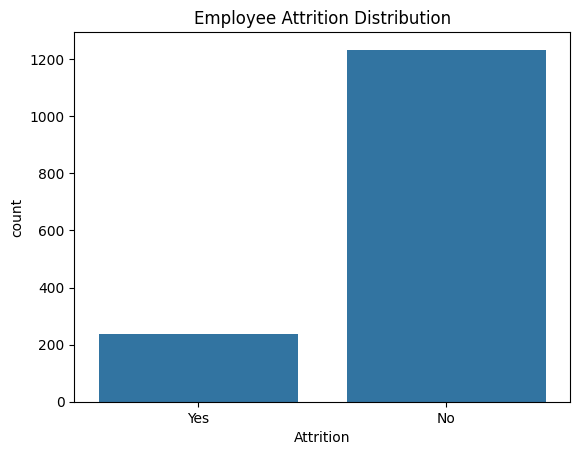

In [11]:
sns.countplot(x="Attrition", data=df)

plt.title("Employee Attrition Distribution")

plt.show()

### Insight

This visualization shows the proportion of employees who stayed versus those who left the company.


##  Demographic Analysis

### Gender Distribution

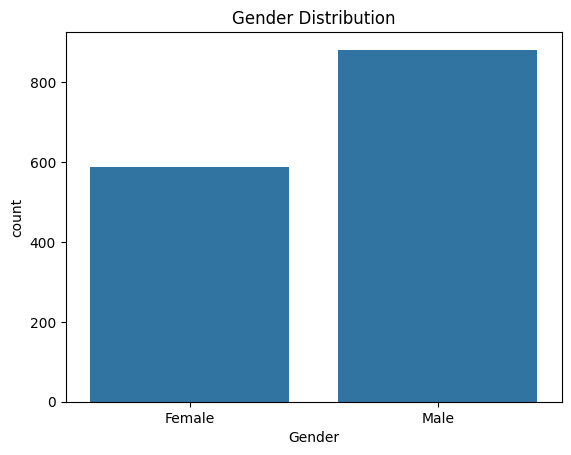

In [16]:
sns.countplot(x="Gender", data=df)

plt.title("Gender Distribution")

plt.show()



### Age Distribution

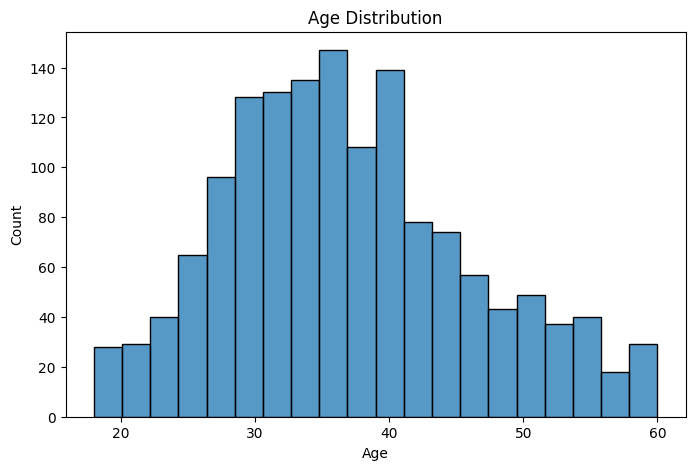

In [13]:
plt.figure(figsize=(8,5))

sns.histplot(df["Age"], bins=20)

plt.title("Age Distribution")

plt.show()

### Key Observation

The workforce consists of employees from different age groups and genders.

### Age vs Attrition

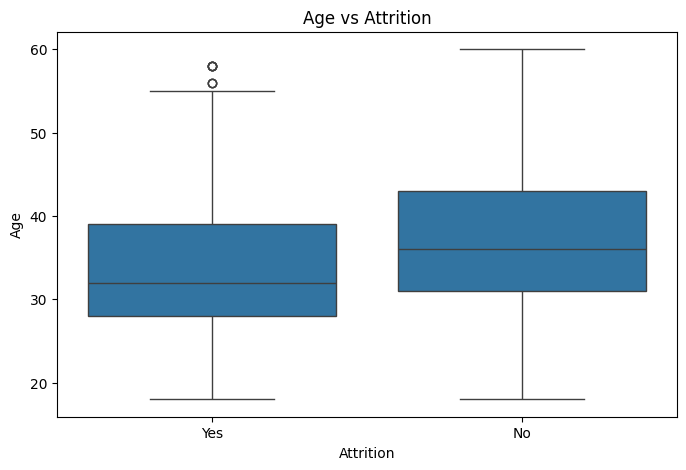

In [14]:
plt.figure(figsize=(8,5))

sns.boxplot(x="Attrition", y="Age", data=df)

plt.title("Age vs Attrition")

plt.show()

### Insight

Analyzing whether younger employees are more likely to leave.

## Compensation Analysis

###  Income Analysis

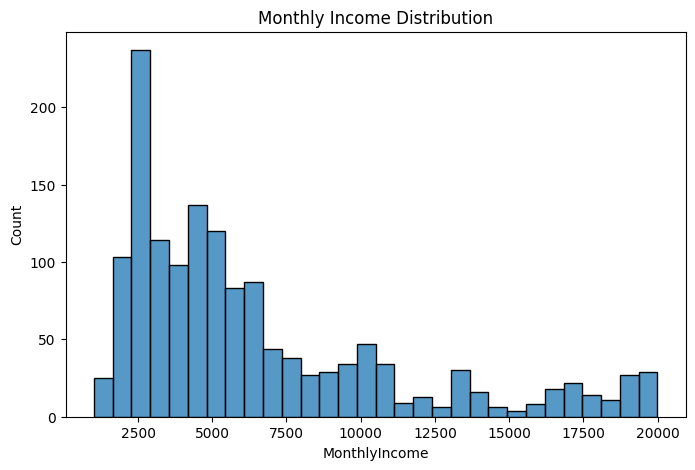

In [18]:
plt.figure(figsize=(8,5))

sns.histplot(df["MonthlyIncome"], bins=30)

plt.title("Monthly Income Distribution")

plt.show()


### Income vs Attrition

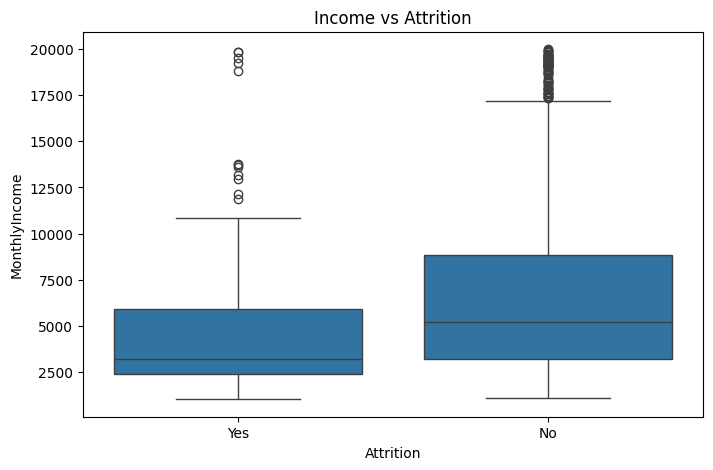

In [19]:
plt.figure(figsize=(8,5))

sns.boxplot(x="Attrition", y="MonthlyIncome", data=df)

plt.title("Income vs Attrition")

plt.show()


### Insight

Evaluating the relationship between compensation and employee turnover.

## Department Analysis

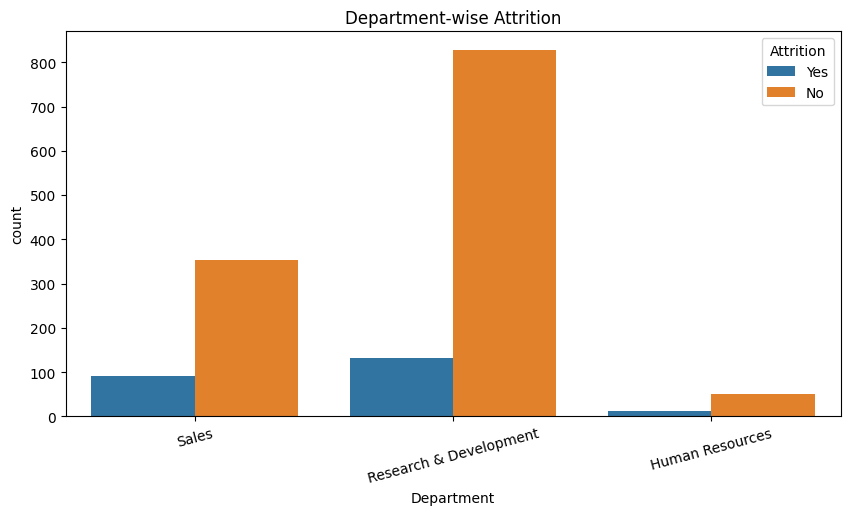

In [20]:
plt.figure(figsize=(10,5))

sns.countplot(x="Department", hue="Attrition", data=df)

plt.title("Department-wise Attrition")

plt.xticks(rotation=15)

plt.show()


### Insight

Some departments appear to have higher attrition levels than others.

## Job Role Analysis

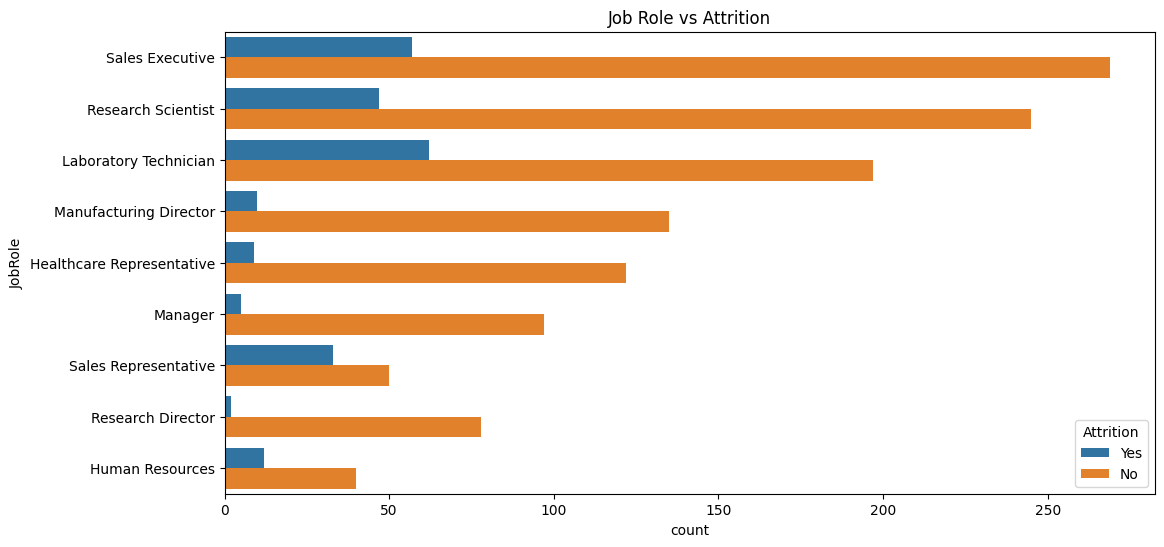

In [22]:
plt.figure(figsize=(12,6))

sns.countplot(y="JobRole", hue="Attrition", data=df)

plt.title("Job Role vs Attrition")

plt.show()

## Overtime Impact

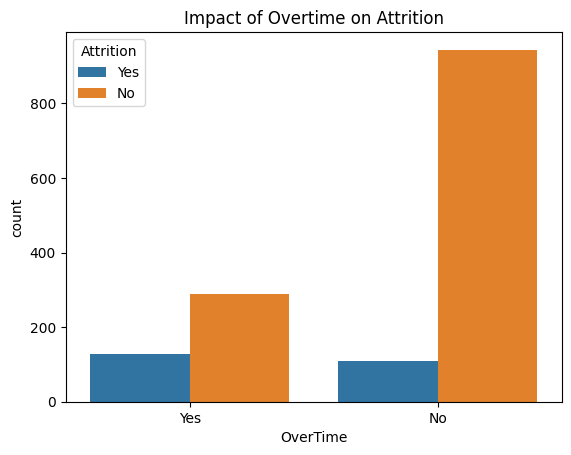

In [23]:
sns.countplot(x="OverTime", hue="Attrition", data=df)

plt.title("Impact of Overtime on Attrition")

plt.show()


### Insight

Employees working overtime show higher attrition trends.

## Job Satisfaction Analysis

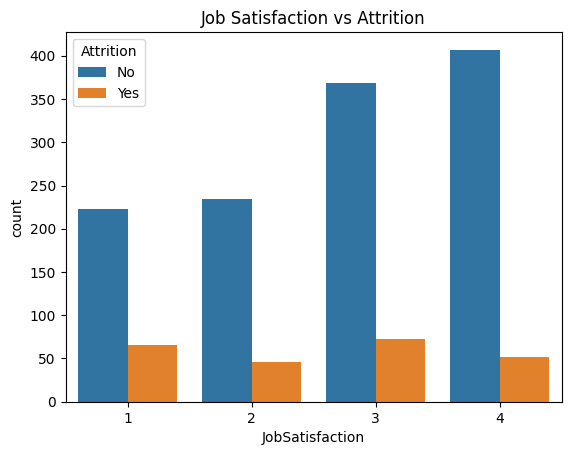

In [24]:
sns.countplot(x="JobSatisfaction", hue="Attrition", data=df)

plt.title("Job Satisfaction vs Attrition")

plt.show()


### Key Observation

Job satisfaction appears to impact employee retention.

## Work-Life Balance Analysis

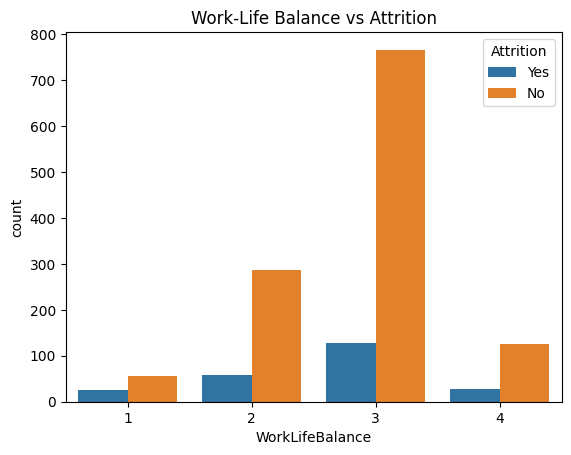

In [25]:
sns.countplot(x="WorkLifeBalance", hue="Attrition", data=df)

plt.title("Work-Life Balance vs Attrition")

plt.show()

### Insight

Poor work-life balance may contribute to employee turnover.

## Years at Company Analysis

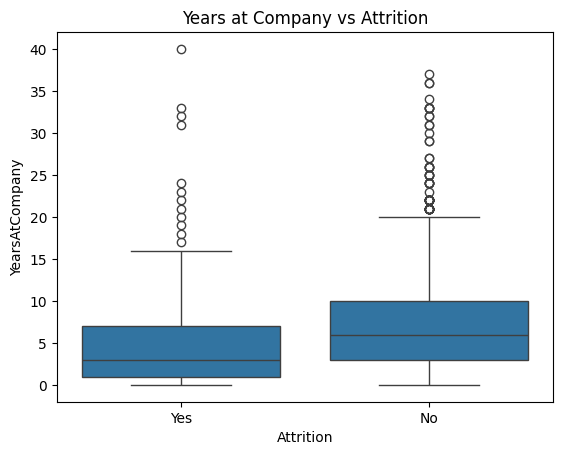

In [27]:
sns.boxplot(x="Attrition", y="YearsAtCompany", data=df)

plt.title("Years at Company vs Attrition")

plt.show()

## Correlation Analysis

In [31]:
numeric_df = df.select_dtypes(include=["int64","float64"])

corr = numeric_df.corr()


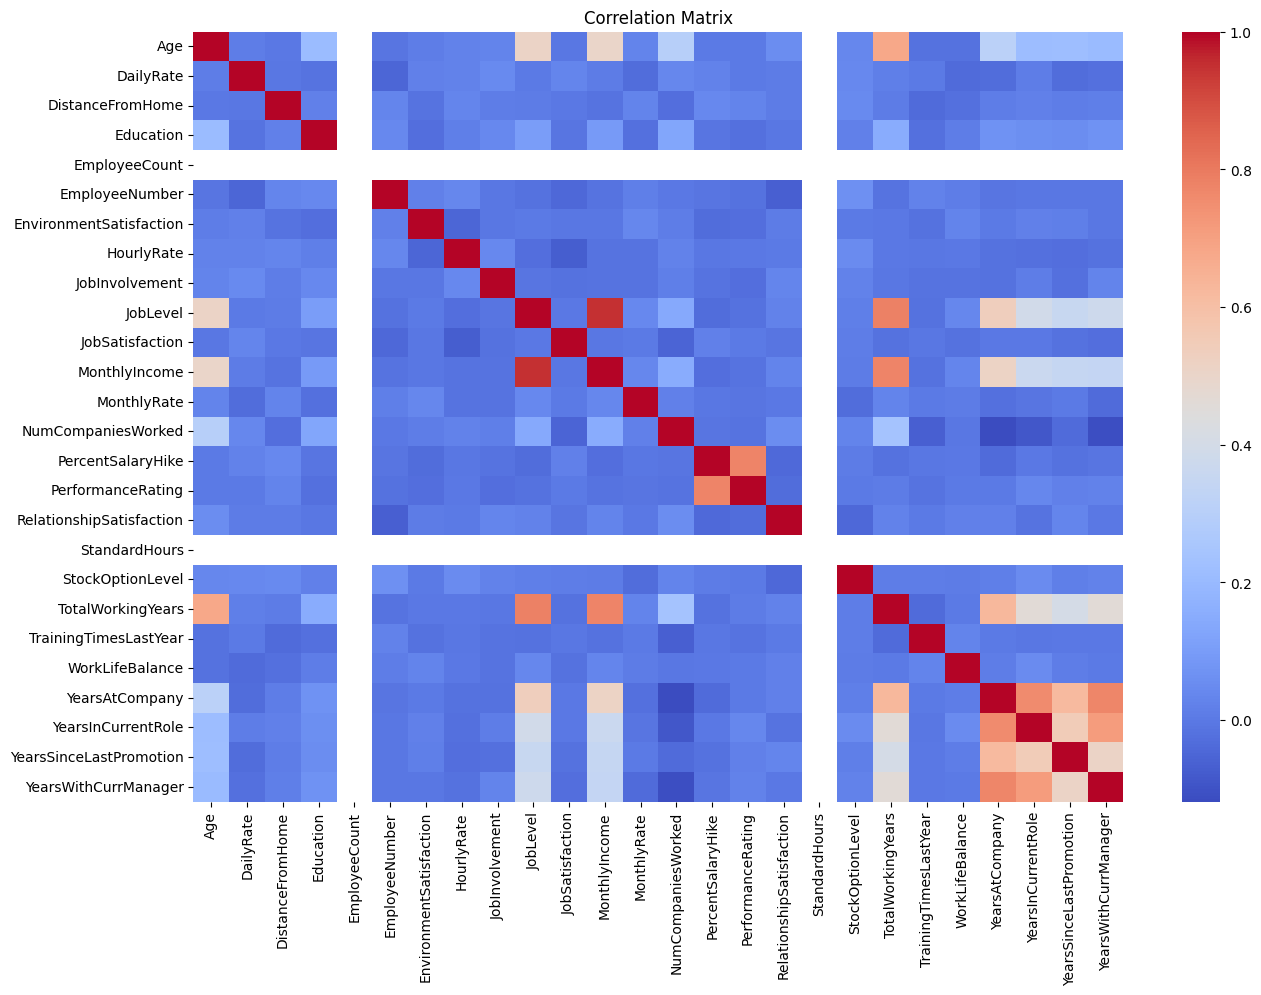

In [32]:
plt.figure(figsize=(15,10))

sns.heatmap(corr, cmap="coolwarm")

plt.title("Correlation Matrix")

plt.show()

### Insight

Several numerical variables show meaningful relationships.

## Key Findings

- Employee attrition is influenced by multiple factors, including overtime, compensation, job satisfaction, and work-life balance.
- Employees working overtime show a higher tendency to leave the organization.
- Lower-income employees exhibit relatively higher attrition rates compared to higher-income employees.
- Job satisfaction and work-life balance appear to have a significant impact on employee retention.
- Certain departments and job roles experience greater employee turnover than others.
- Employee demographics and tenure also contribute to attrition patterns.

## Business Recommendations

- Reduce excessive overtime and promote a healthier work environment.
- Review compensation policies to improve employee satisfaction and retention.
- Strengthen work-life balance initiatives through flexible workplace practices.
- Focus retention strategies on departments and job roles with higher attrition rates.
- Conduct regular employee feedback and satisfaction surveys.
- Invest in employee development, career growth, and engagement programs.

## Conclusion

This project performed an end-to-end exploratory data analysis on employee attrition data using Python. Through data exploration, quality assessment, visualization, and statistical analysis, several factors associated with employee turnover were identified. The analysis highlights the importance of compensation, overtime management, job satisfaction, and work-life balance in retaining employees. These insights can help organizations make informed decisions to improve employee engagement and reduce attrition.